<a href="https://colab.research.google.com/github/Harshavardhan88/ELEVATELABS-TASK5/blob/main/task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Install dependencies

In [1]:
!pip install graphviz
!apt-get install -y graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


# 2: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
import graphviz
from sklearn import tree

# 3: Load dataset & Preprocess the data

In [7]:
df = pd.read_csv("heart.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [23]:
df.duplicated().sum()

np.int64(723)

In [24]:
df.drop_duplicates(inplace=True)

# 4: Features & target

In [25]:
X = df.drop("target", axis=1)
y = df["target"]

# 5: Train-test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6: Train Decision Tree Classifier

In [27]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

# 7: Visualize the Decision Tree

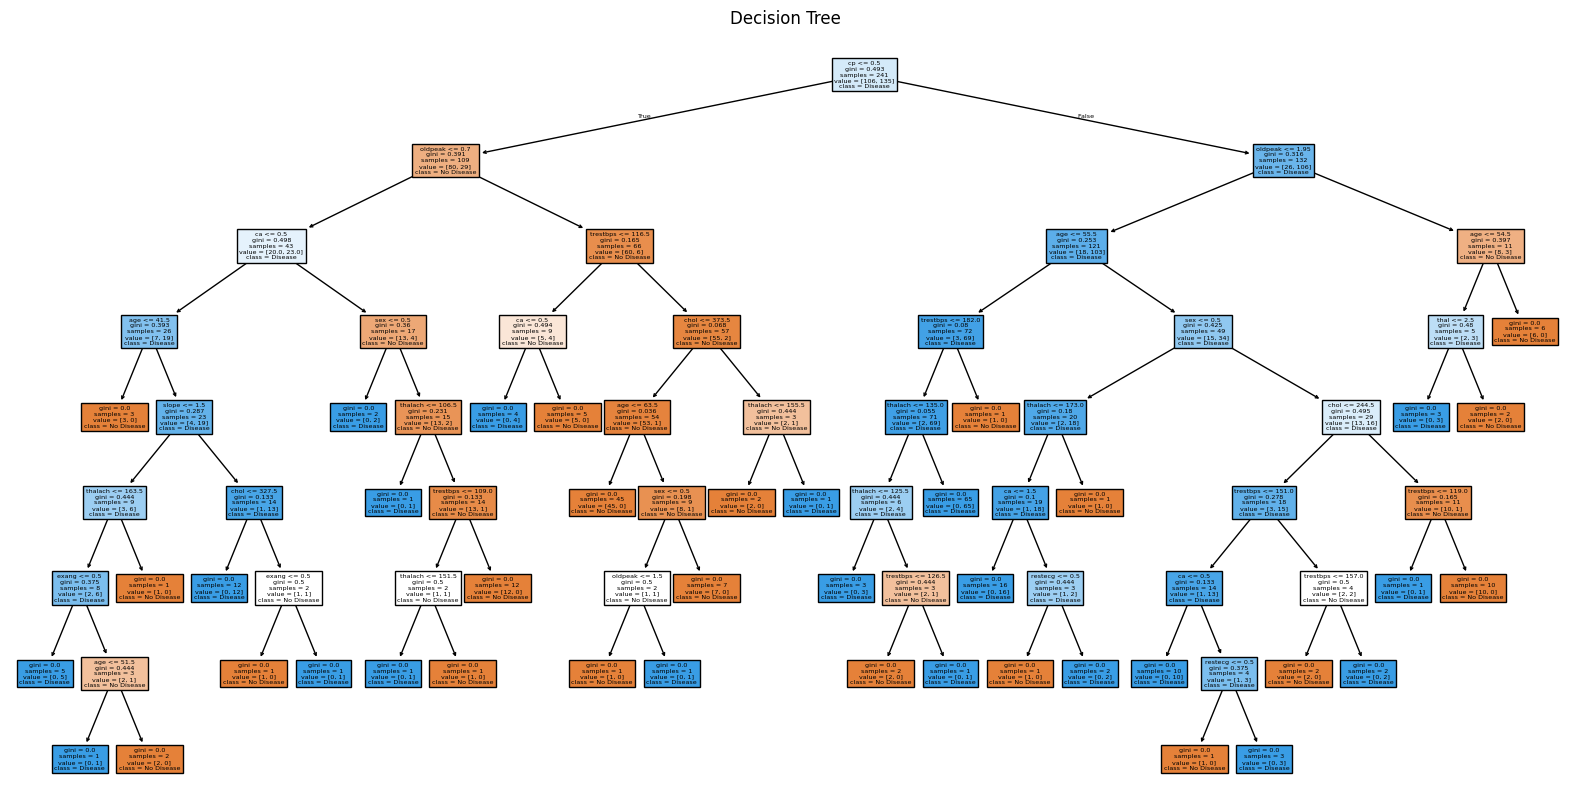

In [28]:
plt.figure(figsize=(20,10))
plot_tree(dtree, filled=True, feature_names=X.columns, class_names=["No Disease", "Disease"])
plt.title("Decision Tree")
plt.show()

# 8: Evaluate and analyze overfitting

In [29]:
train_acc = accuracy_score(y_train, dtree.predict(X_train))
test_acc = accuracy_score(y_test, dtree.predict(X_test))
print(f"Training Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")

Training Accuracy: 1.00
Test Accuracy: 0.74


# 9: Prune the tree by controlling depth

In [30]:
dtree_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

# **Pruned tree evaluation**

In [31]:
train_pruned_acc = accuracy_score(y_train, dtree_pruned.predict(X_train))
test_pruned_acc = accuracy_score(y_test, dtree_pruned.predict(X_test))
print(f"Pruned Tree - Training Accuracy: {train_pruned_acc:.2f}")
print(f"Pruned Tree - Test Accuracy: {test_pruned_acc:.2f}")

Pruned Tree - Training Accuracy: 0.90
Pruned Tree - Test Accuracy: 0.74


# 10: Train Random Forest

In [32]:
rforest = RandomForestClassifier(n_estimators=100, random_state=42)
rforest.fit(X_train, y_train)
rf_preds = rforest.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Test Accuracy: {rf_acc:.2f}")


Random Forest Test Accuracy: 0.84


# 11: Feature importances

In [33]:
importances = rforest.feature_importances_
indices = np.argsort(importances)[::-1]

# **Plot feature importances**

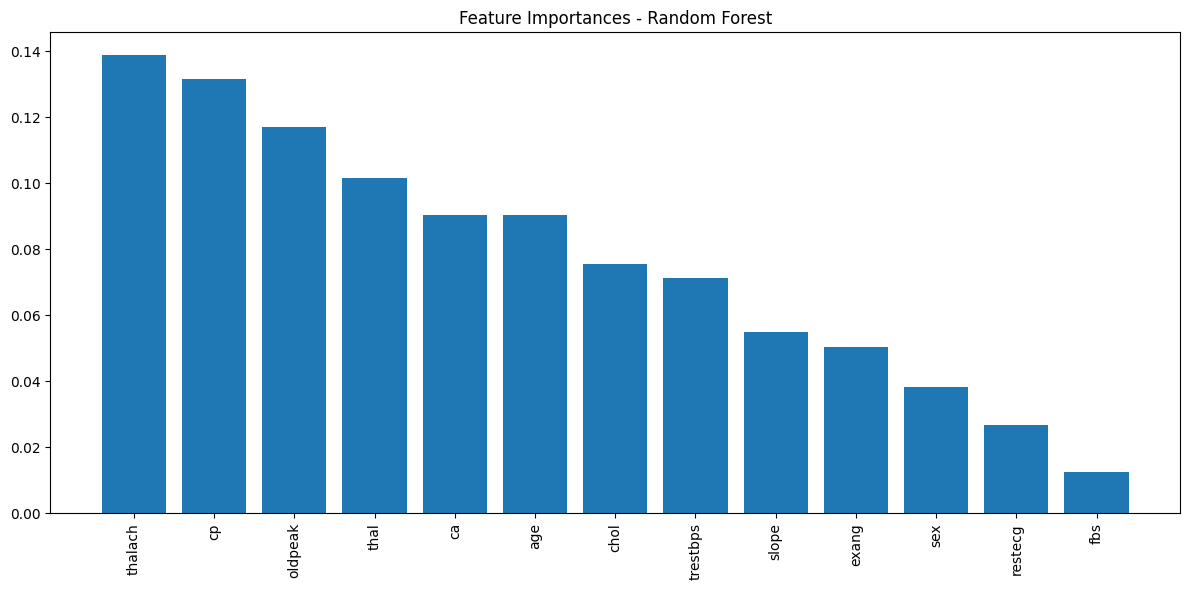

In [34]:
plt.figure(figsize=(12, 6))
plt.title("Feature Importances - Random Forest")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# 12: Cross-validation score

In [35]:
cv_scores = cross_val_score(rforest, X, y, cv=5)
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.2f}")


Cross-Validation Accuracy Scores: [0.83606557 0.81967213 0.9        0.8        0.78333333]
Mean CV Accuracy: 0.83
